# Estudo do uso de llms vs ML clássico SLR2

Aqui tentamos responder a pergunta: **Realmente há ganho no uso de LLMs para a triagem de artigos quando comparado com as abordagem clássicas de aprendizado de máquina?**

In [ ]:
import pandas as pd
import numpy as np
from sklearn.metrics import accuracy_score
import numpy as np
import time
import os
from dotenv import load_dotenv, find_dotenv
from tqdm import tqdm
import matplotlib.pyplot as plt

In [ ]:
import random

random.seed(42)
np.random.seed(42)

In [2]:
### style de execução
tqdm.pandas()

In [3]:
# 1. Configurar para exibir todas as linhas
pd.set_option('display.max_rows', None)

# 2. Configurar para exibir todas as colunas
pd.set_option('display.max_columns', None)

### variaveis de ambiente e conexões

In [4]:
# Carrega as variáveis do arquivo .env
load_dotenv("/data/codigos/.env")

True

In [5]:
for key in os.environ.keys():
    print(f'{key}')

HOSTNAME
HOME
GPG_KEY
PYTHON_SHA256
PATH
LANG
SHELL
PYTHON_VERSION
PWD
VSCODE_CWD
VSCODE_NLS_CONFIG
VSCODE_HANDLES_SIGPIPE
VSCODE_ESM_ENTRYPOINT
VSCODE_HANDLES_UNCAUGHT_ERRORS
REMOTE_CONTAINERS_IPC
REMOTE_CONTAINERS_SOCKETS
SHLVL
_
REMOTE_CONTAINERS
BROWSER
ELECTRON_RUN_AS_NODE
VSCODE_IPC_HOOK_CLI
APPLICATION_INSIGHTS_NO_STATSBEAT
VSCODE_L10N_BUNDLE_LOCATION
PYDEVD_IPYTHON_COMPATIBLE_DEBUGGING
PYTHONUNBUFFERED
PYTHONIOENCODING
PYTHON_FROZEN_MODULES
PYDEVD_USE_FRAME_EVAL
TERM
CLICOLOR
FORCE_COLOR
CLICOLOR_FORCE
PAGER
GIT_PAGER
MPLBACKEND
KMP_DUPLICATE_LIB_OK
KMP_INIT_AT_FORK
OPENAI_API_KEY_GOV_ANALITICA
GOOGLE_API_KEY_LLMS_PROF_DANILO
ANTROPIC_API_KEY_LLMS
TOGETHER_API_KEY_LLMS
GOOGLE_CLOUD_PROJECT
GOOGLE_CLOUD_REGION


## Leitura e processamento do arquivo

In [6]:
df_slr2 = pd.read_excel("/data/codigos/dados/titulo_resumo_palavras_slr2_v2.xlsx",engine='openpyxl')
df_slr2.head()

,ID,Title,resumo,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,flag_pdfs,tentar_via_vpn
0,slr2_1,Redesigning the bartle test of gamer psycholog...,"According to the literature review, to impleme...","Bartle Test, Video Games, Gamification, Motiva...",sucesso,sucesso,não,não estruturado,sim,NaN
1,slr2_2,Towards adaptive gamification: A synthesis of ...,Adaptive gamification is an emerging and fast-...,"Adaptive gamification, structured literature r...",sucesso,sucesso,não,não estruturado,sim,NaN
2,slr2_3,Field guide to gamification: Game components a...,Although digital and analogue games differ in ...,"gamification, mechanical engineering, higher e...",sucesso,sucesso,não,não estruturado,sim,NaN
3,slr2_4,Gamification of eHealth interventions to incre...,Approximately one in five people in the United...,"eHealth, gamification, mental health, user eng...",sucesso,sucesso,não,não estruturado,sim,NaN
4,slr2_5,The relationship between gender and game dynam...,Despite relatively equal participation rate be...,"gender differences, competition, achievement, ...",sucesso,sucesso,não,não estruturado,sim,NaN


In [7]:
df_slr2 = df_slr2.replace({r'_x000D_|\n': ''}, regex=True)

In [8]:
df_slr2.head()

,ID,Title,resumo,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,flag_pdfs,tentar_via_vpn
0,slr2_1,Redesigning the bartle test of gamer psycholog...,"According to the literature review, to impleme...","Bartle Test, Video Games, Gamification, Motiva...",sucesso,sucesso,não,não estruturado,sim,NaN
1,slr2_2,Towards adaptive gamification: A synthesis of ...,Adaptive gamification is an emerging and fast-...,"Adaptive gamification, structured literature r...",sucesso,sucesso,não,não estruturado,sim,NaN
2,slr2_3,Field guide to gamification: Game components a...,Although digital and analogue games differ in ...,"gamification, mechanical engineering, higher e...",sucesso,sucesso,não,não estruturado,sim,NaN
3,slr2_4,Gamification of eHealth interventions to incre...,Approximately one in five people in the United...,"eHealth, gamification, mental health, user eng...",sucesso,sucesso,não,não estruturado,sim,NaN
4,slr2_5,The relationship between gender and game dynam...,Despite relatively equal participation rate be...,"gender differences, competition, achievement, ...",sucesso,sucesso,não,não estruturado,sim,NaN


#### Limpeza dos casos em que não conseguimos extrair as informações


In [9]:
# Calcula a quantidade de valores por nível no campo "sucesso_fracasso"
sucesso_fracasso_counts = df_slr2['sucesso_fracasso_resumo'].value_counts()
print(sucesso_fracasso_counts)

sucesso_fracasso_resumo
sucesso     434
fracasso     14
Name: count, dtype: int64


In [10]:
# Calcula a quantidade de valores por nível no campo "sucesso_fracasso"
sucesso_fracasso_counts2 = df_slr2['sucesso_fracasso_palavras'].value_counts()
print(sucesso_fracasso_counts2)

sucesso_fracasso_palavras
sucesso     392
fracasso     56
Name: count, dtype: int64


In [11]:
# aqui precisamos, para reproduzir o artigo que ambos os campos tenho informação
df_slr2_clear = df_slr2.loc[((df_slr2['sucesso_fracasso_resumo'].isin(['sucesso']))&(df_slr2['sucesso_fracasso_palavras'].isin(['sucesso'])))].copy()
df_slr2_clear.shape

(392, 10)

In [12]:
print(df_slr2_clear["sucesso_fracasso_resumo"].value_counts())
print(df_slr2_clear["sucesso_fracasso_palavras"].value_counts())

sucesso_fracasso_resumo
sucesso    392
Name: count, dtype: int64
sucesso_fracasso_palavras
sucesso    392
Name: count, dtype: int64


In [13]:
print("Shape antes da limpeza: "+str(df_slr2.shape))
print("Shape depois da limpeza"+str(df_slr2_clear.shape))

Shape antes da limpeza: (448, 10)
Shape depois da limpeza(392, 10)


In [14]:
# Renomear as colunas do dataframe df_slr2_clear
df_slr2_clear.rename(columns={"Title": "title", "resumo": "abstract"}, inplace=True)
df_slr2_clear.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,flag_pdfs,tentar_via_vpn
0,slr2_1,Redesigning the bartle test of gamer psycholog...,"According to the literature review, to impleme...","Bartle Test, Video Games, Gamification, Motiva...",sucesso,sucesso,não,não estruturado,sim,NaN
1,slr2_2,Towards adaptive gamification: A synthesis of ...,Adaptive gamification is an emerging and fast-...,"Adaptive gamification, structured literature r...",sucesso,sucesso,não,não estruturado,sim,NaN


### ETL

In [15]:
import re
from sklearn.feature_extraction import text as sk_text

In [16]:
df_slr2_etl = df_slr2_clear.copy()

In [17]:
# se houver NaN, substitui por string vazia
for col in ["title", "abstract", "keywords"]:
    if col not in df_slr2_etl.columns:
        raise ValueError(f"Coluna ausente: {col}")
    df_slr2_etl[col] = df_slr2_etl[col].fillna("").astype(str)

In [18]:
# --- stopwords (inglês, sklearn)
EN_STOPWORDS = set(sk_text.ENGLISH_STOP_WORDS)

In [19]:
# --- limpeza básica: minúsculas, remover pontuação e múltiplos espaços
# obs: mantemos letras, dígitos e hífens (para termos compostos), trocando o resto por espaço
def _clean_series(s: pd.Series) -> pd.Series:
    s = s.str.lower()
    s = s.str.replace(r"[^a-z0-9\-]+", " ", regex=True)   # remove pontuação/sinais
    s = s.str.replace(r"\s+", " ", regex=True).str.strip() # normaliza espaços
    return s


In [20]:
df_slr2_etl["title"]    = _clean_series(df_slr2_etl["title"])
df_slr2_etl["abstract"] = _clean_series(df_slr2_etl["abstract"])
df_slr2_etl["keywords"] = (
    df_slr2_etl["keywords"].str.replace(r"[;,|]", " ", regex=True)  # separadores comuns
                       .pipe(_clean_series)
)

In [21]:
df_slr2_etl.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,flag_pdfs,tentar_via_vpn
0,slr2_1,redesigning the bartle test of gamer psycholog...,according to the literature review to implemen...,bartle test video games gamification motivatio...,sucesso,sucesso,não,não estruturado,sim,NaN
1,slr2_2,towards adaptive gamification a synthesis of c...,adaptive gamification is an emerging and fast-...,adaptive gamification structured literature re...,sucesso,sucesso,não,não estruturado,sim,NaN


In [22]:
print(df_slr2_etl["abstract"].iloc[0])

according to the literature review to implement successful gamification processes of learning it is necessary to know the personality types of gamers who dominate the audience the bartle test is an instrument widely used by video game designers that identify four gamer personalities achievers explorers socializers and killers due to its limitations the bartle test has been improved by updating the items and modifying the structure of questions using the likert scale so that the results objectively represent the types of dominant gamers and the ecosystem of the current games the new test was developed in a web platform to facilitate its application and obtain immediate results which allow making decisions about the elements to be used in the design and development of gamification processes of learning this paper describes the methodology used for the modification of the test and presents results of its application in a pilot group


In [23]:
# --- remoção de stopwords e tokens muito curtos (ex.: 1 char)
def _rm_stop_and_short(s: pd.Series, stopwords=EN_STOPWORDS, min_len=2) -> pd.Series:
    # divide por espaço, remove stopwords e tokens curtos, reagrupa
    def _proc(text: str) -> str:
        toks = text.split()
        toks = [t for t in toks if (t not in stopwords) and (len(t) >= min_len)]
        return " ".join(toks)
    return s.apply(_proc)

In [24]:
df_slr2_etl["title"]    = _rm_stop_and_short(df_slr2_etl["title"])
df_slr2_etl["abstract"] = _rm_stop_and_short(df_slr2_etl["abstract"])
df_slr2_etl["keywords"] = _rm_stop_and_short(df_slr2_etl["keywords"])


In [25]:
print(df_slr2_etl["abstract"].iloc[0])

according literature review implement successful gamification processes learning necessary know personality types gamers dominate audience bartle test instrument widely used video game designers identify gamer personalities achievers explorers socializers killers limitations bartle test improved updating items modifying structure questions using likert scale results objectively represent types dominant gamers ecosystem current games new test developed web platform facilitate application obtain immediate results allow making decisions elements used design development gamification processes learning paper describes methodology used modification test presents results application pilot group


In [26]:
# combinando o titulo, resumo e palavras-chave em um único campo
df_slr2_etl["title_abstract_keywords"]   = (df_slr2_etl["title"] + " " + df_slr2_etl["abstract"] + " " + df_slr2_etl["keywords"]).str.strip()

In [27]:
df_slr2_etl.head(1)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,flag_pdfs,tentar_via_vpn,title_abstract_keywords
0,slr2_1,redesigning bartle test gamer psychology appli...,according literature review implement successf...,bartle test video games gamification motivatio...,sucesso,sucesso,não,não estruturado,sim,NaN,redesigning bartle test gamer psychology appli...


In [28]:
print(df_slr2_etl["title_abstract_keywords"].iloc[0])

redesigning bartle test gamer psychology application gamification processes learning according literature review implement successful gamification processes learning necessary know personality types gamers dominate audience bartle test instrument widely used video game designers identify gamer personalities achievers explorers socializers killers limitations bartle test improved updating items modifying structure questions using likert scale results objectively represent types dominant gamers ecosystem current games new test developed web platform facilitate application obtain immediate results allow making decisions elements used design development gamification processes learning paper describes methodology used modification test presents results application pilot group bartle test video games gamification motivation learning


### Trazendo o rotulo

In [29]:
# vamos trazer os dados disponibilizados pelos autores para comparação de performance
df_slr2_autores = pd.read_excel("/data/codigos/dados/slr2-results-keys.xlsx",engine='openpyxl')
df_slr2_autores.head()

,ID,Title,IC1,IC2,Benchmark,Execution time (s),Total Tokens
0,slr2_1,Redesigning the bartle test of gamer psycholog...,6,6,E,"1,7697742920136",777
1,slr2_2,Towards adaptive gamification: A synthesis of ...,5,5,I,"1,26788704199134",889
2,slr2_3,Field guide to gamification: Game components a...,7,7,I,"1,3752188339713",1233
3,slr2_4,Gamification of eHealth interventions to incre...,1,2,I,"1,54043745799572",1047
4,slr2_5,The relationship between gender and game dynam...,6,6,I,1.338598,1175


In [30]:
print("Shape antes do merge: "+str(df_slr2_etl.shape))
df_slr2_etl = pd.merge(left=df_slr2_etl, right=df_slr2_autores[["ID","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
print("Shape depois do merge: "+str(df_slr2_etl.shape))

Shape antes do merge: (392, 11)
Shape depois do merge: (392, 12)


In [31]:
def convert_benchmark(df,col1):
    df["result_bench"] = np.where(df[col1].str.lower()=="i",1,0)
    return df

In [32]:

df_slr2_etl = convert_benchmark(df_slr2_etl,"Benchmark")

In [33]:
df_slr2_etl.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,flag_pdfs,tentar_via_vpn,title_abstract_keywords,Benchmark,result_bench
0,slr2_1,redesigning bartle test gamer psychology appli...,according literature review implement successf...,bartle test video games gamification motivatio...,sucesso,sucesso,não,não estruturado,sim,NaN,redesigning bartle test gamer psychology appli...,E,0
1,slr2_2,adaptive gamification synthesis current develo...,adaptive gamification emerging fast-growing re...,adaptive gamification structured literature re...,sucesso,sucesso,não,não estruturado,sim,NaN,adaptive gamification synthesis current develo...,I,1


##  modelagem

### TF-IDF e Split

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [35]:
df_slr2_etl["result_bench"].value_counts(normalize=True)

result_bench
0    0.67602
1    0.32398
Name: proportion, dtype: float64

In [36]:
test_size = 50/len(df_slr2_etl)
print("Tamanho do dataset: "+str(len(df_slr2_etl)))
print("Tamanho do dataset de teste em proporção: "+str(test_size))

Tamanho do dataset: 392
Tamanho do dataset de teste em proporção: 0.12755102040816327


In [37]:
# so verificando o valor precisa ser 50
test_size*len(df_slr2_etl)

50.0

In [38]:

idx = np.arange(len(df_slr2_etl))  # índices de linha
y_df = df_slr2_etl["result_bench"].astype(int).values

idx_tr, idx_te, y_tr, y_te = train_test_split(
    idx, y_df,
    test_size=(1-test_size), random_state=42, stratify=y_df
)

# marque no DF para uso futuro
df_slr2_etl["split"] = "train"
df_slr2_etl.loc[idx_te, "split"] = "test"

In [39]:
# se quiser coleções com os IDs correspondentes (atenção: podem repetir)
ids_train = df_slr2_etl.loc[idx_tr, "ID"].tolist()
ids_test  = df_slr2_etl.loc[idx_te, "ID"].tolist()

In [40]:
len(ids_train), len(ids_test)

(50, 342)

In [41]:
# depois você pode filtrar:
df_train = df_slr2_etl[df_slr2_etl["split"]=="train"].copy()
df_test  = df_slr2_etl[df_slr2_etl["split"]=="test"].copy()

# e pegar os textos/labels
X_tr_text = df_train["title_abstract_keywords"]
X_te_text = df_test["title_abstract_keywords"]
y_tr = df_train["result_bench"].astype(int).values
y_te = df_test["result_bench"].astype(int).values


In [42]:
# 3) Vetorização TF-IDF (fit no treino, transform no teste)
tfidf = TfidfVectorizer(
    stop_words="english",   # ok manter, mesmo com limpeza prévia
    ngram_range=(1,2),      # unigrams+bigramas (ajuste se quiser)
    max_features=50000,
    min_df=2,
    sublinear_tf=True,
    lowercase=True,
    norm="l2"
)

X_tr = tfidf.fit_transform(X_tr_text)   # só treino
X_te  = tfidf.transform(X_te_text)      # aplica ao teste

print("Shapes TF-IDF:", X_tr.shape, X_te.shape)

Shapes TF-IDF: (50, 1031) (342, 1031)


In [43]:
X_tr

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 3724 stored elements and shape (50, 1031)>

### Treino e avaliacao do modelo simples

In [44]:
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    RocCurveDisplay, PrecisionRecallDisplay,
    average_precision_score, classification_report,
    confusion_matrix
)

In [ ]:
clf = LogisticRegression(
    solver="liblinear",      # bom para dados esparsos
    penalty="l2",
    class_weight="balanced", # útil se classes desbalanceadas
    max_iter=1000,
    random_state=42,
    n_jobs=None              # remova se versão do sklearn não aceitar
)
clf.fit(X_tr, y_tr)

LogisticRegression(class_weight='balanced', max_iter=1000, solver='liblinear')

In [46]:
y_proba = clf.predict_proba(X_te)[:, 1]  # probabilidade da classe positiva
y_pred  = (y_proba >= 0.5).astype(int)   # decisão com threshold 0.5 (ajustável)

In [47]:
acc  = accuracy_score(y_te, y_pred)
f1   = f1_score(y_te, y_pred)
auc  = roc_auc_score(y_te, y_proba)
ap   = average_precision_score(y_te, y_proba)  # área sob PR (AP)

print(f"Accuracy: {acc:.4f}")
print(f"F1-score: {f1:.4f}")
print(f"ROC-AUC : {auc:.4f}")
print(f"PR-AUC (AP): {ap:.4f}")
print("\nClassification report:\n", classification_report(y_te, y_pred, digits=3))



Accuracy: 0.7953
F1-score: 0.6759
ROC-AUC : 0.8537
PR-AUC (AP): 0.6889

Classification report:
               precision    recall  f1-score   support

           0      0.840     0.861     0.850       231
           1      0.695     0.658     0.676       111

    accuracy                          0.795       342
   macro avg      0.767     0.760     0.763       342
weighted avg      0.793     0.795     0.794       342



In [48]:
# (opcional) Matriz de confusão
cm = confusion_matrix(y_te, y_pred)
print("Confusion matrix:\n", cm)

Confusion matrix:
 [[199  32]
 [ 38  73]]


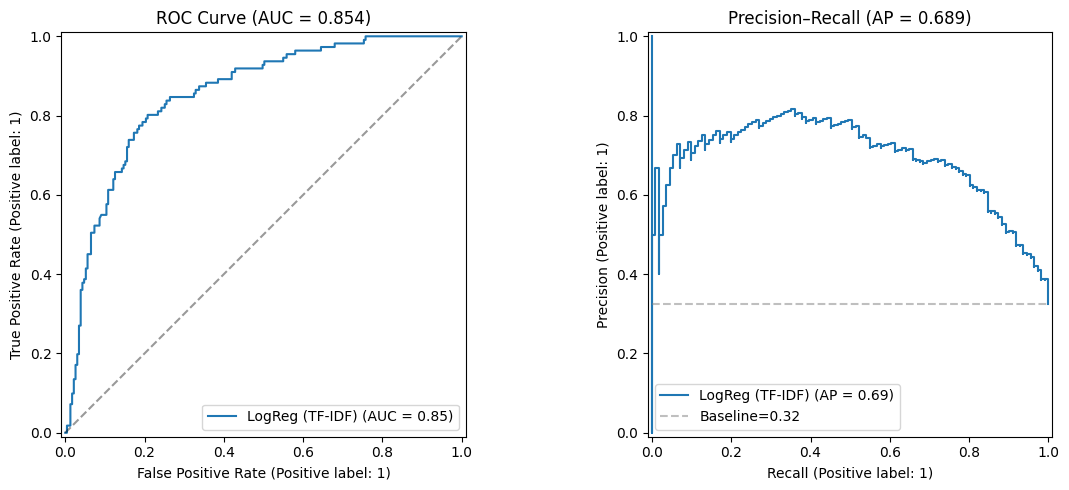

In [49]:
fig, ax = plt.subplots(1, 2, figsize=(12, 5))

RocCurveDisplay.from_predictions(
    y_te, y_proba,
    name="LogReg (TF-IDF)",
    ax=ax[0]
)
ax[0].plot([0,1], [0,1], 'k--', alpha=0.4)
ax[0].set_title(f"ROC Curve (AUC = {auc:.3f})")

# ----- 5) Curva Precision–Recall ---------------------------------------------
PrecisionRecallDisplay.from_predictions(
    y_te, y_proba,
    name="LogReg (TF-IDF)",
    ax=ax[1]
)
# linha de base = prevalência da classe positiva
pos_rate = np.mean(y_te)
ax[1].hlines(pos_rate, 0, 1, colors="gray", linestyles="--", alpha=0.5, label=f"Baseline={pos_rate:.2f}")
ax[1].legend(loc="lower left")
ax[1].set_title(f"Precision–Recall (AP = {ap:.3f})")

plt.tight_layout()
plt.show()

### Treino de vários modelos

In [50]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB

In [51]:
def get_scores(clf, X):
    """
    Retorna um vetor de 'scores' contínuos para métricas baseadas em ranking:
      - Se tiver predict_proba, usa proba[:,1]
      - Senão, usa decision_function
      - Como fallback (raro), usa a predição binária (pobre para AUC/AP)
    """
    if hasattr(clf, "predict_proba"):
        return clf.predict_proba(X)[:, 1]
    elif hasattr(clf, "decision_function"):
        s = clf.decision_function(X)
        # garantir 1D
        return s.ravel() if hasattr(s, "ravel") else s
    else:
        return clf.predict(X).astype(float)

# ----------------------------------
# util: bootstrap CI para Acc e F1
# ----------------------------------
def bootstrap_ci_acc_f1(y_true, y_pred, B=2000, seed=123):
    """
    Bootstrap simples no conjunto de teste para IC95% de Accuracy e F1.
    Aceita pandas Series ou arrays; converte para NumPy internamente.
    """
    # --- garante NumPy 1D ---
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()

    assert y_true.shape == y_pred.shape, "y_true e y_pred com comprimentos diferentes."

    rng = np.random.default_rng(seed)
    n = y_true.shape[0]

    accs = np.empty(B, dtype=float)
    f1s  = np.empty(B, dtype=float)

    for b in range(B):
        idx = rng.integers(0, n, size=n)  # amostra índices [0..n-1]
        yt  = y_true[idx]
        yp  = y_pred[idx]
        accs[b] = accuracy_score(yt, yp)
        f1s[b]  = f1_score(yt, yp, zero_division=0)

    lo_acc, hi_acc = np.percentile(accs, [2.5, 97.5])
    lo_f1,  hi_f1  = np.percentile(f1s,  [2.5, 97.5])

    return {
        "acc": float(accs.mean()), "acc_lo": float(lo_acc), "acc_hi": float(hi_acc),
        "f1":  float(f1s.mean()),  "f1_lo":  float(lo_f1),  "f1_hi":  float(hi_f1),
    }



In [ ]:
# -------------------------------------------------
# modelos a rodar (configurações razoáveis p/ TF-IDF)
# -------------------------------------------------
models = {
    "LogReg": LogisticRegression(
        solver="liblinear",
        penalty="l2",
        class_weight="balanced",
        max_iter=1000,
        random_state=42,
    ),
    "RandomForest": RandomForestClassifier(
        n_estimators=300,
        max_depth=None,
        class_weight="balanced_subsample",
        n_jobs=-1,
        random_state=42
    ),
    "SVC": SVC(
        kernel="linear",          # linear costuma ir bem com TF-IDF
        probability=True,         # para ter predict_proba (necessário p/ AUC/AP)
        class_weight="balanced",
        random_state=42
    ),
    "MultinomialNB": MultinomialNB(alpha=0.5)  # NB costuma ser forte com TF-IDF
}

rows = []

for name, clf in models.items():
    # --- treino ---
    clf.fit(X_tr, y_tr)

    # --- predição (teste) ---
    y_pred  = clf.predict(X_te)
    y_score = get_scores(clf, X_te)

    # --- métricas ponto ---
    acc = accuracy_score(y_te, y_pred)
    f1  = f1_score(y_te, y_pred, zero_division=0)

    # métricas baseadas em ranking (precisam de y_score contínuo)
    try:
        auc = roc_auc_score(y_te, y_score)
    except ValueError:
        # pode falhar se só houver uma classe no y_te
        auc = np.nan
    try:
        ap  = average_precision_score(y_te, y_score)
    except ValueError:
        ap = np.nan

    # --- IC95% por bootstrap (apenas Acc/F1, conforme pedido) ---
    b = bootstrap_ci_acc_f1(y_te, y_pred, B=2000, seed=123)

    rows.append({
        "model": name,
        "accuracy": acc,
        "accuracy_lo": b["acc_lo"],
        "accuracy_hi": b["acc_hi"],
        "f1": f1,
        "f1_lo": b["f1_lo"],
        "f1_hi": b["f1_hi"],
        "roc_auc": auc,
        "pr_ap": ap
    })

df_ml_eval = pd.DataFrame(rows).sort_values("model").reset_index(drop=True)

In [53]:
df_ml_eval

,model,accuracy,accuracy_lo,accuracy_hi,f1,f1_lo,f1_hi,roc_auc,pr_ap
0,LogReg,0.795322,0.751389,0.839181,0.675926,0.595723,0.746547,0.853730,0.688886
1,MultinomialNB,0.698830,0.649123,0.748538,0.188976,0.096759,0.276435,0.799715,0.617453
2,RandomForest,0.704678,0.654971,0.751462,0.217054,0.128000,0.316687,0.848056,0.692623
3,SVC,0.783626,0.736842,0.827485,0.622449,0.535515,0.698276,0.839144,0.669066


### Trazendo os resultados dos modelos de llms

In [54]:
df_gpt41 = pd.read_csv("/data/codigos/dados/resultados/reproducao_resultados_openai_gpt_41_slr2_v2.csv",encoding='utf-8')
df_gpt41.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,flag_pdfs,tentar_via_vpn,gpt-4.1_IC1_0,gpt-4.1_IC1_1,gpt-4.1_IC1_2,gpt-4.1_IC1_3,gpt-4.1_IC1_4,gpt-4.1_IC2_0,gpt-4.1_IC2_1,gpt-4.1_IC2_2,gpt-4.1_IC2_3,gpt-4.1_IC2_4
0,slr2_1,Redesigning the bartle test of gamer psycholog...,"According to the literature review, to impleme...","Bartle Test, Video Games, Gamification, Motiva...",sucesso,sucesso,não,não estruturado,sim,NaN,6,6,6,6,6,6,6,6,6,6
1,slr2_2,Towards adaptive gamification: A synthesis of ...,Adaptive gamification is an emerging and fast-...,"Adaptive gamification, structured literature r...",sucesso,sucesso,não,não estruturado,sim,NaN,6,6,6,6,6,6,6,6,6,6


In [56]:
df_gemini_25_flash = pd.read_csv("/data/codigos/dados/resultados/reproducao_resultados_gemini_pro_slr2_v2.csv",encoding='utf-8')
df_gemini_25_flash.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,flag_pdfs,tentar_via_vpn,gemini-2.5-flash_IC1_0,gemini-2.5-flash_IC1_1,gemini-2.5-flash_IC1_2,gemini-2.5-flash_IC1_3,gemini-2.5-flash_IC1_4,gemini-2.5-flash_IC2_0,gemini-2.5-flash_IC2_1,gemini-2.5-flash_IC2_2,gemini-2.5-flash_IC2_3,gemini-2.5-flash_IC2_4
0,slr2_1,Redesigning the bartle test of gamer psycholog...,"According to the literature review, to impleme...","Bartle Test, Video Games, Gamification, Motiva...",sucesso,sucesso,não,não estruturado,sim,NaN,6,7,7,7,7,3,3,2,3,3
1,slr2_2,Towards adaptive gamification: A synthesis of ...,Adaptive gamification is an emerging and fast-...,"Adaptive gamification, structured literature r...",sucesso,sucesso,não,não estruturado,sim,NaN,7,7,7,7,7,7,7,7,7,7


In [57]:
df_claude_sonnet_35 = pd.read_csv("/data/codigos/dados/resultados/reproducao_resultados_claude_sonnet_35_slr2_v2.csv",encoding='utf-8')
df_claude_sonnet_35.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,flag_pdfs,tentar_via_vpn,claude-3-5-sonnet-20241022_IC1_0,claude-3-5-sonnet-20241022_IC1_1,claude-3-5-sonnet-20241022_IC1_2,claude-3-5-sonnet-20241022_IC1_3,claude-3-5-sonnet-20241022_IC1_4,claude-3-5-sonnet-20241022_IC2_0,claude-3-5-sonnet-20241022_IC2_1,claude-3-5-sonnet-20241022_IC2_2,claude-3-5-sonnet-20241022_IC2_3,claude-3-5-sonnet-20241022_IC2_4
0,slr2_1,Redesigning the bartle test of gamer psycholog...,"According to the literature review, to impleme...","Bartle Test, Video Games, Gamification, Motiva...",sucesso,sucesso,não,não estruturado,sim,NaN,7,7,7,7,7,5,5,5,5,5
1,slr2_2,Towards adaptive gamification: A synthesis of ...,Adaptive gamification is an emerging and fast-...,"Adaptive gamification, structured literature r...",sucesso,sucesso,não,não estruturado,sim,NaN,6,6,6,6,6,6,6,6,6,6


In [58]:
df_llama = pd.read_csv("/data/codigos/dados/resultados/reproducao_resultados_Llama-4-Scout-17B-16E-Instruct_slr2_v2.csv",encoding='utf-8')
df_llama.head(2)

,ID,title,abstract,keywords,sucesso_fracasso_resumo,sucesso_fracasso_palavras,segunda_coleta,obs,flag_pdfs,tentar_via_vpn,Llama-4-Scout-17B-16E-Instruct_IC1_0,Llama-4-Scout-17B-16E-Instruct_IC1_1,Llama-4-Scout-17B-16E-Instruct_IC1_2,Llama-4-Scout-17B-16E-Instruct_IC1_3,Llama-4-Scout-17B-16E-Instruct_IC1_4,Llama-4-Scout-17B-16E-Instruct_IC2_0,Llama-4-Scout-17B-16E-Instruct_IC2_1,Llama-4-Scout-17B-16E-Instruct_IC2_2,Llama-4-Scout-17B-16E-Instruct_IC2_3,Llama-4-Scout-17B-16E-Instruct_IC2_4
0,slr2_1,Redesigning the bartle test of gamer psycholog...,"According to the literature review, to impleme...","Bartle Test, Video Games, Gamification, Motiva...",sucesso,sucesso,não,não estruturado,sim,NaN,2,2,2,2,2,2,2,2,2,2
1,slr2_2,Towards adaptive gamification: A synthesis of ...,Adaptive gamification is an emerging and fast-...,"Adaptive gamification, structured literature r...",sucesso,sucesso,não,não estruturado,sim,NaN,7,7,7,7,7,5,5,5,5,5


In [59]:
# vamos trazer os dados disponibilizados pelos autores para comparação de performance
df_slr2_autores = pd.read_excel("/data/codigos/dados/slr2-results-keys.xlsx",engine='openpyxl')
df_slr2_autores.head()

,ID,Title,IC1,IC2,Benchmark,Execution time (s),Total Tokens
0,slr2_1,Redesigning the bartle test of gamer psycholog...,6,6,E,"1,7697742920136",777
1,slr2_2,Towards adaptive gamification: A synthesis of ...,5,5,I,"1,26788704199134",889
2,slr2_3,Field guide to gamification: Game components a...,7,7,I,"1,3752188339713",1233
3,slr2_4,Gamification of eHealth interventions to incre...,1,2,I,"1,54043745799572",1047
4,slr2_5,The relationship between gender and game dynam...,6,6,I,1.338598,1175


In [60]:
df_gpt41 = pd.merge(left=df_gpt41, right=df_slr2_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_gpt41.shape

(392, 23)

In [61]:
df_gemini_25_flash = pd.merge(left=df_gemini_25_flash, right=df_slr2_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_gemini_25_flash.shape


(392, 23)

In [62]:
df_claude_sonnet_35 = pd.merge(left=df_claude_sonnet_35, right=df_slr2_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_claude_sonnet_35.shape

(392, 23)

In [63]:
df_llama = pd.merge(left=df_llama, right=df_slr2_autores[["ID","IC1","IC2","Benchmark"]],
                          left_on='ID', right_on='ID',how='left')
df_llama.shape

(392, 23)

In [64]:
# criando a regra do corte em 5
def convert_benchmark(df,col1):
    df["result_bench"] = np.where(df[col1].str.lower()=="i",1,0)
    return df

In [65]:
df_gpt41 = convert_benchmark(df_gpt41,"Benchmark")

In [66]:
df_gemini_25_flash = convert_benchmark(df_gemini_25_flash,"Benchmark")

In [67]:
df_claude_sonnet_35 = convert_benchmark(df_claude_sonnet_35,"Benchmark")

In [68]:
df_llama = convert_benchmark(df_llama,"Benchmark")

In [69]:
def create_result_llm_classic(df,col1,col2,limit1,limit2,col_name):
    """
    Create flag with result for llms
    """
    df["aux_ic1"] = np.where(df[col1]>=limit1,1,0)
    df["aux_ic2"] = np.where(df[col2]>=limit2,1,0)
    df[col_name] = np.where(((df["aux_ic1"]==1) & (df["aux_ic2"]==1)),1,0)
    return df.drop(columns=["aux_ic1","aux_ic2"])

In [70]:
# Cria a resposta final para cada iteração
def calculate_select_result_llm(n_interactions, model_gpt, df):
    name_ic1 = "IC1"
    name_ic2 = "IC2"
    for i in range(n_interactions):
        coluna_aux1 = model_gpt+"_"+name_ic1+"_"+str(i)
        coluna_aux2 = model_gpt+"_"+name_ic2+"_"+str(i)
        col_name = model_gpt+"_"+str(i)
        df = create_result_llm_classic(df=df,
                                        col1=coluna_aux1,
                                        col2=coluna_aux2,
                                        limit1=5,
                                        limit2=5,
                                        col_name=col_name)
    return df

In [71]:
n_interactions = 5
model_gpt = "gpt-4.1"
df_gpt41 = calculate_select_result_llm(n_interactions=n_interactions, model_gpt=model_gpt, df=df_gpt41)

In [72]:
model_gpt = "gemini-2.5-flash"
df_gemini_25_flash = calculate_select_result_llm(n_interactions=n_interactions, model_gpt=model_gpt, df=df_gemini_25_flash)

In [74]:
model_gpt = "claude-3-5-sonnet-20241022"
df_claude_sonnet_35 = calculate_select_result_llm(n_interactions=n_interactions, model_gpt=model_gpt, df=df_claude_sonnet_35)

In [75]:
model_gpt = "Llama-4-Scout-17B-16E-Instruct"
df_llama = calculate_select_result_llm(n_interactions=n_interactions, model_gpt=model_gpt, df=df_llama)

In [76]:
def filtra_resultado_llm(df,model,interation):
    colname=model+"_"+str(interation)
    return df[["ID","result_bench",colname]]



In [77]:
def processa_llm(ids_test,df,df_ml_eval,model,interation):
    # filtra apenas os casos que foram pra teste
    print("df antes do filtro: "+str(df.shape))
    df = df[df["ID"].isin(ids_test)].copy()
    print("df depois do filtro: "+str(df.shape))
    
    df_result = filtra_resultado_llm(df,model=model,interation=interation)
    y_true = df_result["result_bench"].astype(int).values
    y_pred = df_result[model+"_"+str(interation)].astype(int).values
     # --- métricas ponto ---
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, zero_division=0)
    boots = bootstrap_ci_acc_f1(y_true, y_pred, B=2000, seed=123)

    row = {
            "model": model,
            "accuracy": acc,
            "accuracy_lo": boots["acc_lo"],
            "accuracy_hi": boots["acc_hi"],
            "f1": f1,
            "f1_lo": boots["f1_lo"],
            "f1_hi": boots["f1_hi"],
            "roc_auc": np.nan,
            "pr_ap": np.nan
        }
    new_row_df = pd.DataFrame([row])
    df_ml_eval = pd.concat([df_ml_eval, new_row_df], ignore_index=True)
    return df_ml_eval

In [78]:
df_ml_eval = processa_llm(ids_test=ids_test,
                          df=df_gpt41,
                          df_ml_eval=df_ml_eval,
                          model="gpt-4.1",
                          interation=4)

df antes do filtro: (392, 29)
df depois do filtro: (342, 29)


In [79]:
df_ml_eval

,model,accuracy,accuracy_lo,accuracy_hi,f1,f1_lo,f1_hi,roc_auc,pr_ap
0,LogReg,0.795322,0.751389,0.839181,0.675926,0.595723,0.746547,0.853730,0.688886
1,MultinomialNB,0.698830,0.649123,0.748538,0.188976,0.096759,0.276435,0.799715,0.617453
2,RandomForest,0.704678,0.654971,0.751462,0.217054,0.128000,0.316687,0.848056,0.692623
3,SVC,0.783626,0.736842,0.827485,0.622449,0.535515,0.698276,0.839144,0.669066
4,gpt-4.1,0.830409,0.789474,0.868421,0.728972,0.660000,0.792457,NaN,NaN


In [80]:
df_ml_eval = processa_llm(ids_test=ids_test,
                          df=df_gemini_25_flash,
                          df_ml_eval=df_ml_eval,
                          model="gemini-2.5-flash",
                          interation=4)

df antes do filtro: (392, 29)
df depois do filtro: (342, 29)


In [81]:
df_ml_eval

,model,accuracy,accuracy_lo,accuracy_hi,f1,f1_lo,f1_hi,roc_auc,pr_ap
0,LogReg,0.795322,0.751389,0.839181,0.675926,0.595723,0.746547,0.853730,0.688886
1,MultinomialNB,0.698830,0.649123,0.748538,0.188976,0.096759,0.276435,0.799715,0.617453
2,RandomForest,0.704678,0.654971,0.751462,0.217054,0.128000,0.316687,0.848056,0.692623
3,SVC,0.783626,0.736842,0.827485,0.622449,0.535515,0.698276,0.839144,0.669066
4,gpt-4.1,0.830409,0.789474,0.868421,0.728972,0.660000,0.792457,NaN,NaN
5,gemini-2.5-flash,0.789474,0.745614,0.830482,0.709677,0.642841,0.770504,NaN,NaN


In [82]:
df_ml_eval = processa_llm(ids_test=ids_test,
                          df=df_claude_sonnet_35,
                          df_ml_eval=df_ml_eval,
                          model="claude-3-5-sonnet-20241022",
                          interation=4)

df antes do filtro: (392, 29)
df depois do filtro: (342, 29)


In [83]:
df_ml_eval

,model,accuracy,accuracy_lo,accuracy_hi,f1,f1_lo,f1_hi,roc_auc,pr_ap
0,LogReg,0.795322,0.751389,0.839181,0.675926,0.595723,0.746547,0.853730,0.688886
1,MultinomialNB,0.698830,0.649123,0.748538,0.188976,0.096759,0.276435,0.799715,0.617453
2,RandomForest,0.704678,0.654971,0.751462,0.217054,0.128000,0.316687,0.848056,0.692623
3,SVC,0.783626,0.736842,0.827485,0.622449,0.535515,0.698276,0.839144,0.669066
4,gpt-4.1,0.830409,0.789474,0.868421,0.728972,0.660000,0.792457,NaN,NaN
5,gemini-2.5-flash,0.789474,0.745614,0.830482,0.709677,0.642841,0.770504,NaN,NaN
6,claude-3-5-sonnet-20241022,0.821637,0.780702,0.859649,0.726457,0.654545,0.790914,NaN,NaN


In [84]:
df_ml_eval = processa_llm(ids_test=ids_test,
                          df=df_llama,
                          df_ml_eval=df_ml_eval,
                          model="Llama-4-Scout-17B-16E-Instruct",
                          interation=4)

df antes do filtro: (392, 29)
df depois do filtro: (342, 29)


In [85]:
df_ml_eval

,model,accuracy,accuracy_lo,accuracy_hi,f1,f1_lo,f1_hi,roc_auc,pr_ap
0,LogReg,0.795322,0.751389,0.839181,0.675926,0.595723,0.746547,0.853730,0.688886
1,MultinomialNB,0.698830,0.649123,0.748538,0.188976,0.096759,0.276435,0.799715,0.617453
2,RandomForest,0.704678,0.654971,0.751462,0.217054,0.128000,0.316687,0.848056,0.692623
3,SVC,0.783626,0.736842,0.827485,0.622449,0.535515,0.698276,0.839144,0.669066
4,gpt-4.1,0.830409,0.789474,0.868421,0.728972,0.660000,0.792457,NaN,NaN
5,gemini-2.5-flash,0.789474,0.745614,0.830482,0.709677,0.642841,0.770504,NaN,NaN
6,claude-3-5-sonnet-20241022,0.821637,0.780702,0.859649,0.726457,0.654545,0.790914,NaN,NaN
7,Llama-4-Scout-17B-16E-Instruct,0.681287,0.631579,0.730994,0.035398,0.000000,0.087719,NaN,NaN


#### Acuracia

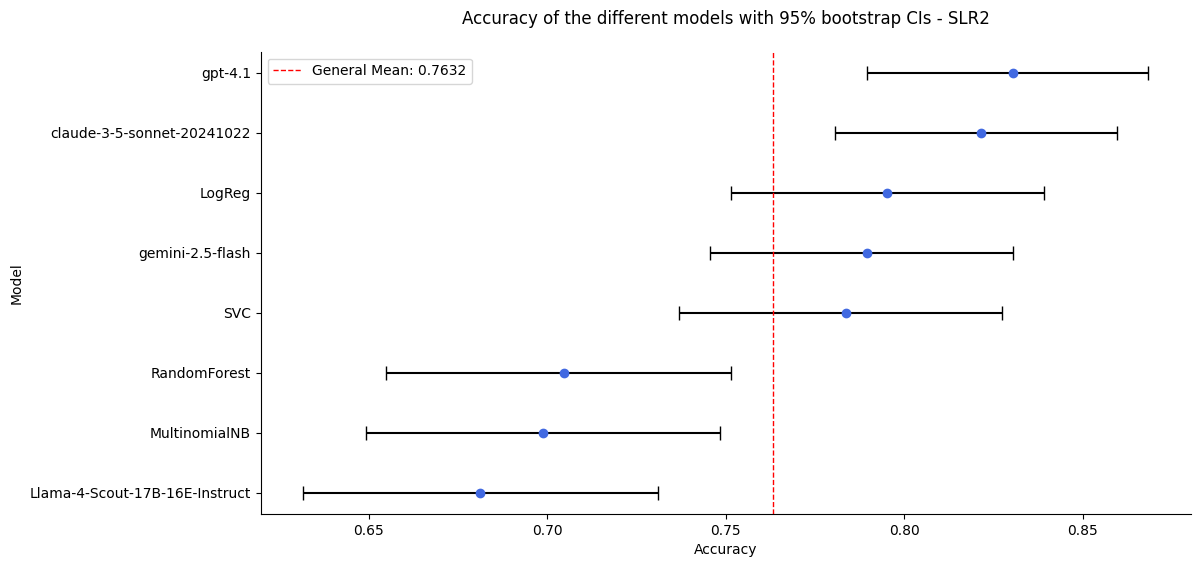

In [86]:
# Ordena o DataFrame em ordem decrescente de accuracy média
variavel_metrica = "accuracy"
lim_inf="accuracy_lo"
lim_sup="accuracy_hi"
df_estatisticas = df_ml_eval.sort_values(by=variavel_metrica, ascending=True)

# Cria o gráfico de fatores de influência com modelo na vertical e accuracy na horizontal
fig, ax = plt.subplots()
fig.set_size_inches(12, 6)

# Plota os pontos centrais (médias) e as barras de erro (limites inferior e superior)
ax.errorbar(df_estatisticas[variavel_metrica], df_estatisticas['model'], 
            xerr=[df_estatisticas[variavel_metrica] - df_estatisticas[lim_inf], 
                  df_estatisticas[lim_sup] - df_estatisticas[variavel_metrica]], 
            fmt='o', color='royalblue', ecolor='black', capsize=5)

# Calcula a média das médias
media_das_medias = df_estatisticas[variavel_metrica].mean()

# Traça a linha horizontal representando a média das médias
ax.axvline(media_das_medias, color='red', linestyle='--', linewidth=1, label=f'General Mean: {media_das_medias:.4f}')

# Ajusta o título e os rótulos
plt.title("Accuracy of the different models with 95% bootstrap CIs - SLR2", pad=20)
plt.ylabel('Model')
plt.xlabel('Accuracy')
plt.legend()

# Remover bordas desnecessárias
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Exibe o gráfico
plt.show()

In [ ]:
# Ordena o DataFrame em ordem crescente (fica do menor para o maior na horizontal)
variavel_metrica = "accuracy"
lim_inf = "accuracy_lo"
lim_sup = "accuracy_hi"
df_estatisticas = df_ml_eval.sort_values(by=variavel_metrica, ascending=True)

# Gráfico
fig, ax = plt.subplots(figsize=(12, 8))

# Pontos + barras de erro
x = df_estatisticas[variavel_metrica].values
y = df_estatisticas['model'].values
xm = (df_estatisticas[variavel_metrica] - df_estatisticas[lim_inf]).values
xp = (df_estatisticas[lim_sup] - df_estatisticas[variavel_metrica]).values

ax.errorbar(x, y, xerr=[xm, xp], fmt='o', color='royalblue',
            ecolor='black', capsize=5, elinewidth=1.5, markersize=6)

# Linha da média
media_das_medias = df_estatisticas[variavel_metrica].mean()
ax.axvline(media_das_medias, color='red', linestyle='--', linewidth=1,
           label=f'General Mean: {media_das_medias:.4f}')

# ---- Anotações nos pontos (valor central + IC) ----
# pequeno deslocamento horizontal (2% do range)
xmin = float(df_estatisticas[lim_inf].min())
xmax = float(df_estatisticas[lim_sup].max())
rng  = xmax - xmin if xmax > xmin else 1.0
dx   = 0.02 * rng
dx = 0
for xi, yi, lo, hi in zip(x, y, df_estatisticas[lim_inf], df_estatisticas[lim_sup]):
    txt = f"{xi:.2f} [{lo:.2f}, {hi:.2f}]"    
    ax.text(xi - dx, yi, txt, ha='center', va='bottom', fontsize=13, color='#333333')
   

# Título, eixos e legenda
ax.set_title("Accuracy of the different models with 95% bootstrap CIs", pad=20, fontsize=18)
ax.set_ylabel('Model',fontsize=16)
ax.set_xlabel('Accuracy', fontsize=16)
ax.legend(loc='lower right', fontsize=13)
ax.tick_params(axis='both', labelsize=16)

# Margem no eixo X para não cortar textos
ax.set_xlim(xmin - 0.05*rng, xmax + 0.05*rng)

# Limpeza visual
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid( linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('/data/codigos/dados/resultados/figuras/slr2_fase_3_acuracia.png', dpi=300, bbox_inches="tight")
plt.show()


#### F1 score

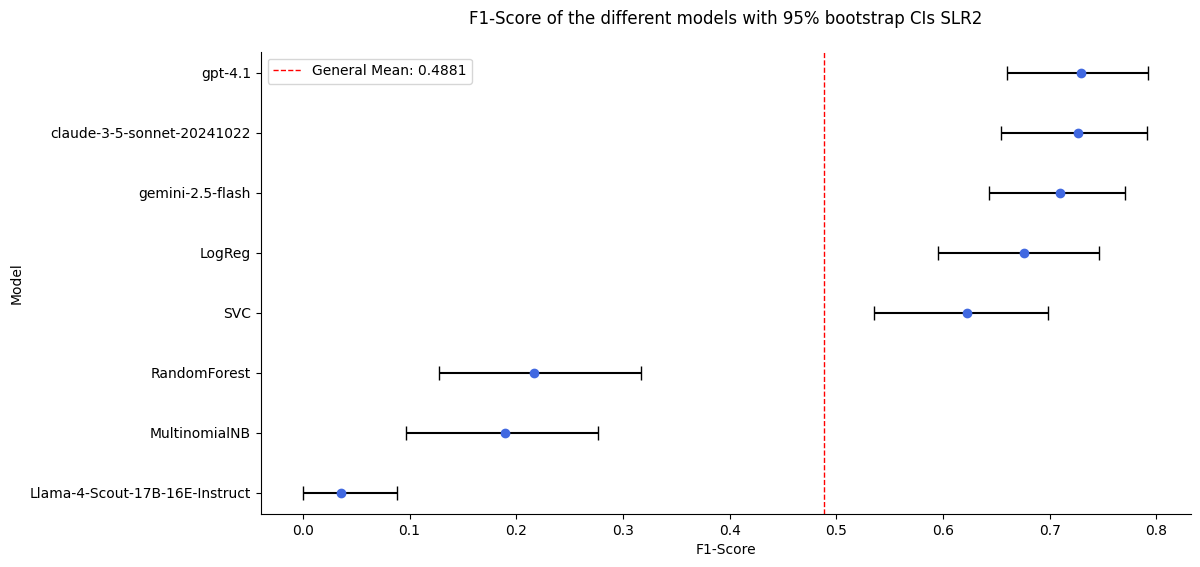

In [87]:
# Ordena o DataFrame em ordem decrescente de f1 média
variavel_metrica = "f1"
lim_inf="f1_lo"
lim_sup="f1_hi"
df_estatisticas = df_ml_eval.sort_values(by=variavel_metrica, ascending=True)

# Cria o gráfico de fatores de influência com modelo na vertical e f1 na horizontal
fig, ax = plt.subplots()
fig.set_size_inches(12, 6)

# Plota os pontos centrais (médias) e as barras de erro (limites inferior e superior)
ax.errorbar(df_estatisticas[variavel_metrica], df_estatisticas['model'], 
            xerr=[df_estatisticas[variavel_metrica] - df_estatisticas[lim_inf], 
                  df_estatisticas[lim_sup] - df_estatisticas[variavel_metrica]], 
            fmt='o', color='royalblue', ecolor='black', capsize=5)

# Calcula a média das médias
media_das_medias = df_estatisticas[variavel_metrica].mean()

# Traça a linha horizontal representando a média das médias
ax.axvline(media_das_medias, color='red', linestyle='--', linewidth=1, label=f'General Mean: {media_das_medias:.4f}')

# Ajusta o título e os rótulos
plt.title("F1-Score of the different models with 95% bootstrap CIs SLR2", pad=20)
plt.ylabel('Model')
plt.xlabel('F1-Score')
plt.legend()

# Remover bordas desnecessárias
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Exibe o gráfico
plt.show()

In [ ]:
# Ordena o DataFrame em ordem decrescente de f1 média
variavel_metrica = "f1"
lim_inf="f1_lo"
lim_sup="f1_hi"
df_estatisticas = df_ml_eval.sort_values(by=variavel_metrica, ascending=True)

# Cria o gráfico de fatores de influência com modelo na vertical e f1 na horizontal
fig, ax = plt.subplots()
fig.set_size_inches(12, 6)

# Plota os pontos centrais (médias) e as barras de erro (limites inferior e superior)
ax.errorbar(df_estatisticas[variavel_metrica], df_estatisticas['model'], 
            xerr=[df_estatisticas[variavel_metrica] - df_estatisticas[lim_inf], 
                  df_estatisticas[lim_sup] - df_estatisticas[variavel_metrica]], 
            fmt='o', color='royalblue', ecolor='black', capsize=5)

# Calcula a média das médias
media_das_medias = df_estatisticas[variavel_metrica].mean()

# Traça a linha horizontal representando a média das médias
ax.axvline(media_das_medias, color='red', linestyle='--', linewidth=1, label=f'General Mean: {media_das_medias:.4f}')

# ---- Anotações nos pontos (valor central + IC) ----
# pequeno deslocamento horizontal (2% do range)
xmin = float(df_estatisticas[lim_inf].min())
xmax = float(df_estatisticas[lim_sup].max())
rng  = xmax - xmin if xmax > xmin else 1.0
dx   = 0.02 * rng
dx = 0
for xi, yi, lo, hi in zip(x, y, df_estatisticas[lim_inf], df_estatisticas[lim_sup]):
    txt = f"{xi:.2f} [{lo:.2f}, {hi:.2f}]"    
    ax.text(xi - dx, yi, txt, ha='center', va='bottom', fontsize=13, color='#333333')

# Ajusta o título e os rótulos
plt.title("F1-Score of the different models with 95% bootstrap CIs", pad=20,fontsize=18)
ax.set_ylabel('Model',fontsize=16)
ax.set_xlabel('F1-Score', fontsize=16)
ax.legend(loc='lower right', fontsize=13)
ax.tick_params(axis='both', labelsize=16)

# Remover bordas desnecessárias
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)

# Exibe o gráfico
plt.tight_layout()
plt.savefig('/data/codigos/dados/resultados/figuras/slr2_fase_3_f1.png', dpi=300, bbox_inches="tight")
plt.show()

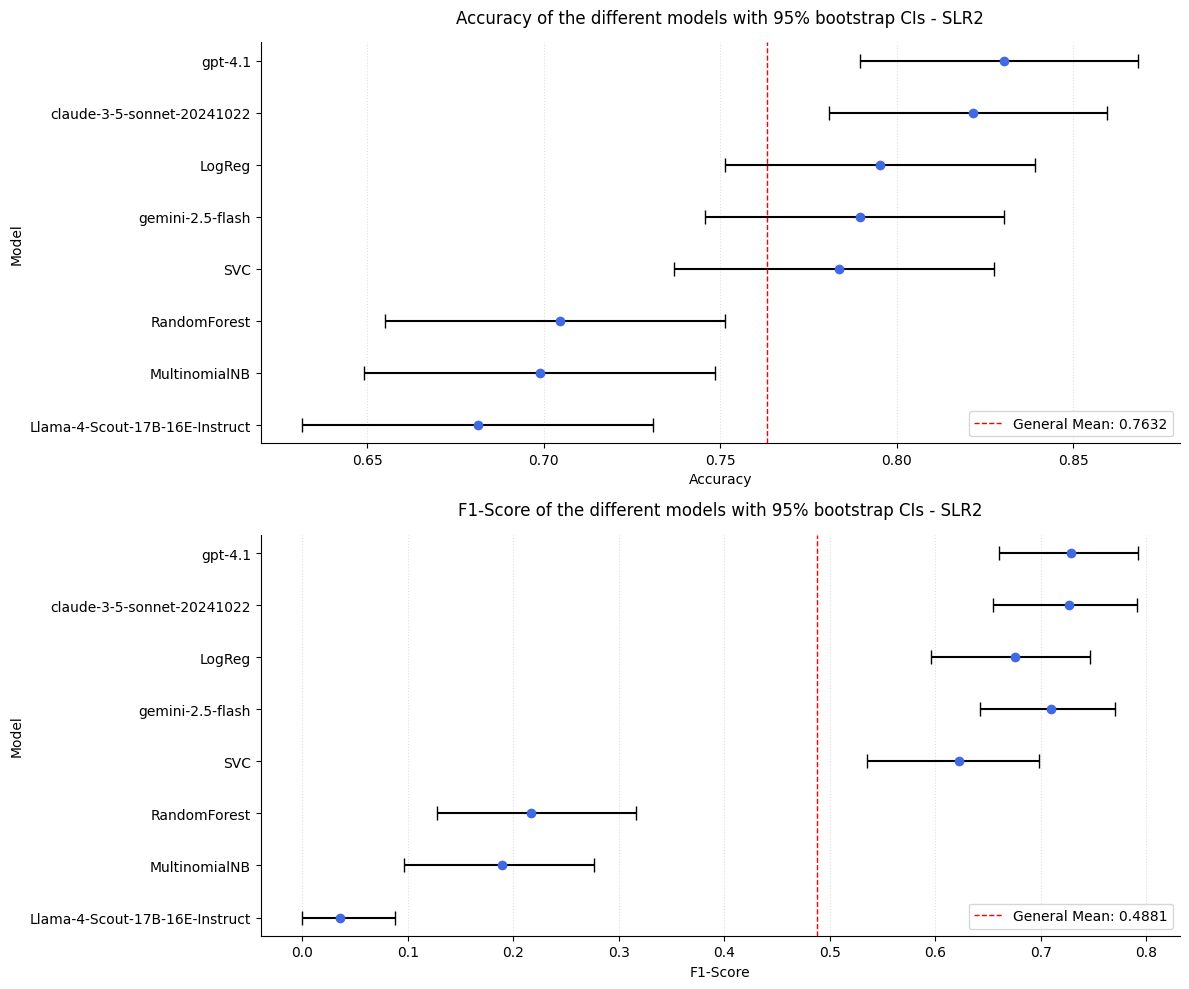

In [88]:

# --- 1) Ordenação única pelos modelos (use a de accuracy para manter alinhado)
order = (df_ml_eval.sort_values(by="accuracy", ascending=True)["model"]).tolist()

# --- 2) DataFrames ordenados conforme 'order'
acc_cols = ("accuracy", "accuracy_lo", "accuracy_hi")
f1_cols  = ("f1", "f1_lo", "f1_hi")

df_acc = df_ml_eval.set_index("model").loc[order].reset_index()
df_f1  = df_ml_eval.set_index("model").loc[order].reset_index()

# --- 3) Figura com 2 subplots empilhados
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharey=True)

# ====== PLOT 1: Accuracy ======
variavel_metrica, lim_inf, lim_sup = acc_cols
x  = df_acc[variavel_metrica]
xm = df_acc[variavel_metrica] - df_acc[lim_inf]
xp = df_acc[lim_sup] - df_acc[variavel_metrica]
y  = df_acc["model"]

ax1.errorbar(x, y, xerr=[xm, xp], fmt='o', color='royalblue', ecolor='black', capsize=5)
media_acc = x.mean()
ax1.axvline(media_acc, color='red', linestyle='--', linewidth=1, label=f'General Mean: {media_acc:.4f}')
ax1.set_title("Accuracy of the different models with 95% bootstrap CIs - SLR2", pad=14)
ax1.set_xlabel("Accuracy")
ax1.set_ylabel("Model")
ax1.legend(loc="lower right")
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(axis="x", linestyle=":", alpha=0.4)

# ====== PLOT 2: F1 ======
variavel_metrica, lim_inf, lim_sup = f1_cols
x  = df_f1[variavel_metrica]
xm = df_f1[variavel_metrica] - df_f1[lim_inf]
xp = df_f1[lim_sup] - df_f1[variavel_metrica]
y  = df_f1["model"]

ax2.errorbar(x, y, xerr=[xm, xp], fmt='o', color='royalblue', ecolor='black', capsize=5)
media_f1 = x.mean()
ax2.axvline(media_f1, color='red', linestyle='--', linewidth=1, label=f'General Mean: {media_f1:.4f}')
ax2.set_title("F1-Score of the different models with 95% bootstrap CIs - SLR2", pad=14)
ax2.set_xlabel("F1-Score")
ax2.set_ylabel("Model")
ax2.legend(loc="lower right")
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis="x", linestyle=":", alpha=0.4)

plt.tight_layout()
plt.show()

In [ ]:
# ---------- Ordem única (pela accuracy) para alinhar os dois gráficos ----------
order = df_ml_eval.sort_values(by="accuracy", ascending=True)["model"].tolist()

# DataFrames reindexados na mesma ordem
df_acc = df_ml_eval.set_index("model").loc[order].reset_index()
df_f1  = df_ml_eval.set_index("model").loc[order].reset_index()

# ---------- Figura com 2 subplots empilhados, Y compartilhado ----------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), sharey=True)

# ===================== PLOT 1 — ACCURACY =====================
variavel_metrica, lim_inf, lim_sup = "accuracy", "accuracy_lo", "accuracy_hi"

x  = df_acc[variavel_metrica].values
y  = df_acc["model"].values
xm = (df_acc[variavel_metrica] - df_acc[lim_inf]).values
xp = (df_acc[lim_sup] - df_acc[variavel_metrica]).values

ax1.errorbar(x, y, xerr=[xm, xp], fmt='o', color='royalblue',
             ecolor='black', capsize=5, elinewidth=1.5, markersize=6)

# linha da média
media_acc = x.mean()
ax1.axvline(media_acc, color='red', linestyle='--', linewidth=1,
            label=f'General Mean: {media_acc:.4f}')

# anotações
xmin = float(df_acc[lim_inf].min())
xmax = float(df_acc[lim_sup].max())
rng  = xmax - xmin if xmax > xmin else 1.0
dx   = 0.00 * rng  
for xi, yi, lo, hi in zip(x, y, df_acc[lim_inf], df_acc[lim_sup]):
    txt = f"{xi:.2f} [{lo:.2f}, {hi:.2f}]"
    ax1.text(xi - dx, yi, txt, ha='center', va='bottom', fontsize=13, color='#333')

# estética
ax1.set_title("SLR1:Accuracy of the different models with 95% bootstrap CIs", pad=20, fontsize=18)
ax1.set_ylabel('Model', fontsize=16)
ax1.set_xlabel('Accuracy', fontsize=16)
ax1.legend(loc='lower right', fontsize=13)
ax1.tick_params(axis='both', labelsize=16)
ax1.set_xlim(xmin - 0.05*rng, xmax + 0.05*rng)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax1.grid(linestyle=':', alpha=0.5)

# ===================== PLOT 2 — F1 =====================
variavel_metrica, lim_inf, lim_sup = "f1", "f1_lo", "f1_hi"

x  = df_f1[variavel_metrica].values
y  = df_f1["model"].values
xm = (df_f1[variavel_metrica] - df_f1[lim_inf]).values
xp = (df_f1[lim_sup] - df_f1[variavel_metrica]).values

ax2.errorbar(x, y, xerr=[xm, xp], fmt='o', color='royalblue',
             ecolor='black', capsize=5, elinewidth=1.5, markersize=6)

# linha da média
media_f1 = x.mean()
ax2.axvline(media_f1, color='red', linestyle='--', linewidth=1,
            label=f'General Mean: {media_f1:.4f}')

# anotações
xmin2 = float(df_f1[lim_inf].min())
xmax2 = float(df_f1[lim_sup].max())
rng2  = xmax2 - xmin2 if xmax2 > xmin2 else 1.0
dx2   = 0.00 * rng2

for xi, yi, lo, hi in zip(x, y, df_f1[lim_inf], df_f1[lim_sup]):
    txt = f"{xi:.2f} [{lo:.2f}, {hi:.2f}]"
    ax2.text(xi - dx2, yi, txt, ha='center', va='bottom', fontsize=13, color='#333')

# estética
ax2.set_title("SLR1: F1-Score of the different models with 95% bootstrap CIs", pad=20, fontsize=18)
ax2.set_ylabel('Model', fontsize=16)
ax2.set_xlabel('F1-Score', fontsize=16)
ax2.legend(loc='lower right', fontsize=13)
ax2.tick_params(axis='both', labelsize=16)
ax2.set_xlim(xmin2 - 0.05*rng2, xmax2 + 0.05*rng2)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(linestyle=':', alpha=0.5)

plt.tight_layout()
# opcional: salvar figura única
plt.savefig('/data/codigos/dados/resultados/figuras/slr1_fase_3_acc_f1.png', dpi=300, bbox_inches="tight")
plt.show()